<a href="https://colab.research.google.com/github/gomez-L/AI4Phil_ImpactMeasurement/blob/main/nb_colab_01_financial_sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Financial Sustainability Analysis
## Digital Skills Programme · Q1 2026 · Geneva

---

### Purpose
This notebook answers the **financial and operational sustainability** questions of the impact measurement exercise:

| # | Core question |
|---|---------------|
| Q1 | Is the nonprofit programme for digital skills **financially sustainable**? |
| Q5 | How much money is **available for the next iteration** of the programme? |
| Q6 | How much can we **increase the percentage of free seats** while staying sustainable and growing? |
| Q7 | How many **extra free seats** can we offer from the Q1 2026 surplus? |

### Why financial sustainability matters for a nonprofit
Nonprofits must cover costs to survive. Without a positive surplus — even a small one — the organisation cannot reinvest in future editions, keep prices affordable, or maintain the free-seat policy that makes the programme accessible. The **social mission is only deliverable if the economics work**. Impact measurement therefore always includes a financial dimension, commonly called *financial resilience* or *operational sustainability*.

### Data sources used in this notebook
- `data/workshops.csv` — one row per workshop; revenue, costs, surplus
- `data/upcoming_workshops.csv` — planned future workshops used for projection

### Pricing model (Q1 2026)
| Seat type | Price (CHF) |
|-----------|------------|
| Paid onsite | 15 |
| Paid online | 5 |
| Free | 0 |

### Cost structure per workshop
| Cost item | Rule |
|-----------|------|
| Venue | ≤ 150 CHF (onsite only; 0 for online) |
| Instructor | 100 CHF (fixed, good-cause rate) |
| Materials / Marketing / Admin | 0 CHF |

---

In [1]:
import os

# Remove any existing data directory to ensure a clean state
!rm -rf data

# Clone the GitHub repository
!git clone https://github.com/gomez-L/AI4Phil_ImpactMeasurement.git

# Create a 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Move the contents of dat_for_colab to the 'data' directory
!mv AI4Phil_ImpactMeasurement/dat_for_colab/* data/

# Remove the cloned repository to clean up
!rm -rf AI4Phil_ImpactMeasurement

print("Data from 'dat_for_colab' has been successfully retrieved and placed in the 'data' directory.")

Cloning into 'AI4Phil_ImpactMeasurement'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 89 (delta 14), reused 69 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 207.28 KiB | 2.09 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Data from 'dat_for_colab' has been successfully retrieved and placed in the 'data' directory.


In [2]:
# ─── Cell 1 · Import libraries ────────────────────────────────────────────────
# We use pandas for data wrangling, matplotlib/seaborn for static charts,
# numpy for arithmetic, and scipy.stats for any statistical summaries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Consistent visual style across the notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

# All paths relative to the notebook file (project root)
DATA_DIR = Path("data")
print("Libraries loaded. Data directory:", DATA_DIR.resolve())

Libraries loaded. Data directory: /content/data


---
## Section 1 — Load and inspect the workshop financial data

**Why this step?**  
Before any analysis we must understand what we have: column types, completeness, and basic magnitudes.  
Good data hygiene is foundational to credible impact reporting.

In [3]:
# ─── Cell 2 · Load workshop data ──────────────────────────────────────────────
ws = pd.read_csv(DATA_DIR / "workshops.csv", parse_dates=["date"])

# Derive month label and quarter label for time-series grouping
ws["month"] = ws["date"].dt.to_period("M").astype(str)
ws["quarter"] = ws["date"].dt.to_period("Q").astype(str)

# Derive free_seat_pct: the proportion of total seats that were free
ws["free_seat_pct"] = (ws["n_free"] / ws["participants_total"] * 100).round(1)

# Derive margin_pct: net margin expressed as a percentage of revenue
# (undefined when revenue = 0, which would mean a workshop gave everything away)
ws["margin_pct"] = (ws["surplus_chf"] / ws["revenue_chf"].replace(0, np.nan) * 100).round(1)

print(f"Workshops loaded: {len(ws)}")
print(f"Columns: {list(ws.columns)}")
ws[["workshop_id", "name", "date", "topic", "n_free", "revenue_chf", "total_cost_chf", "surplus_chf", "free_seat_pct"]].to_string(index=False)

Workshops loaded: 8
Columns: ['workshop_id', 'name', 'date', 'topic', 'participants_total', 'n_paid_onsite', 'n_paid_online', 'n_free', 'revenue_chf', 'cost_venue_chf', 'cost_materials_chf', 'cost_instructor_chf', 'cost_marketing_chf', 'cost_admin_chf', 'total_cost_chf', 'surplus_chf', 'month', 'quarter', 'free_seat_pct', 'margin_pct']


'workshop_id                             name       date                            topic  n_free  revenue_chf  total_cost_chf  surplus_chf  free_seat_pct\nws_2026_001      Python Basics for Beginners 2026-01-20               Python programming       5        375.0           250.0        125.0           16.7\nws_2026_002         Cybersecurity Essentials 2026-02-10          Cybersecurity awareness       5        125.0           100.0         25.0           16.7\nws_2026_003    Data Literacy for Non-Profits 2026-03-15                    Data literacy       5        375.0           220.0        155.0           16.7\nws_2026_004             Statistics Beginners 2026-04-05             statistics beginners       5        125.0           100.0         25.0           16.7\nws_2026_005          Statistics Intermediate 2026-04-25          statistics intermediate       5        125.0           100.0         25.0           16.7\nws_2026_006 Introduction to Programming in R 2026-05-12 introduction 

In [ ]:
# ─── Cell 3 · Summary statistics ──────────────────────────────────────────────
# We round floats to 2 dp for readability.
summary_cols = ["revenue_chf", "total_cost_chf", "surplus_chf", "free_seat_pct", "margin_pct"]
desc = ws[summary_cols].describe().round(2)
print("=== Financial summary statistics (all workshops) ===")
print(desc)

---
## Section 2 — Q1: Is the programme financially sustainable?

**Why this is the core question**  
A programme is *operationally sustainable* when, over a relevant accounting period, total revenue at least covers total costs — ideally with a positive surplus to fund growth.  
We look at three lenses:
1. **Workshop-level surplus** — is each edition viable on its own?
2. **Aggregate Q1 2026 result** — is the quarter in the green?
3. **Revenue vs. cost structure** — do the unit economics scale?

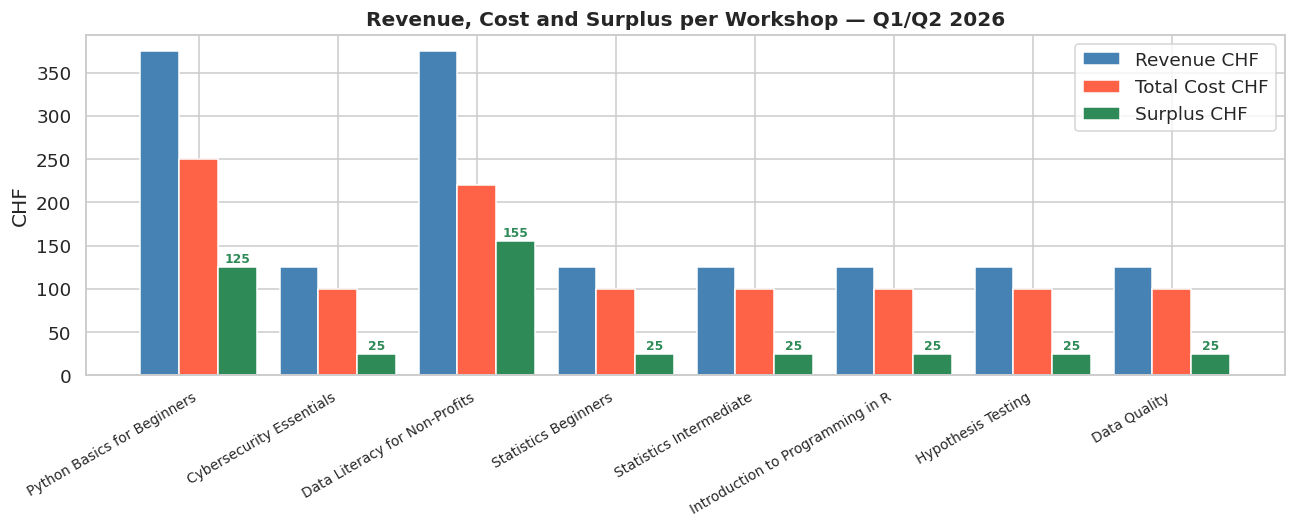


All workshops produced a positive surplus: True
Minimum surplus: CHF 25.00 (Cybersecurity Essentials)
Maximum surplus: CHF 155.00 (Data Literacy for Non-Profits)


In [4]:
# ─── Cell 4 · Workshop-level revenue / cost / surplus bar chart ───────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(ws))
width = 0.28

bars_rev  = ax.bar(x - width, ws["revenue_chf"],    width, label="Revenue CHF",    color="steelblue")
bars_cost = ax.bar(x,         ws["total_cost_chf"], width, label="Total Cost CHF", color="tomato")
bars_sur  = ax.bar(x + width, ws["surplus_chf"],    width, label="Surplus CHF",    color="seagreen")

# Annotate each surplus bar with its value
for bar in bars_sur:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 2, f"{h:.0f}",
            ha="center", va="bottom", fontsize=8, color="seagreen", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(ws["name"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("CHF")
ax.set_title("Revenue, Cost and Surplus per Workshop — Q1/Q2 2026", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Interpretation banner
all_positive = (ws["surplus_chf"] > 0).all()
print(f"\nAll workshops produced a positive surplus: {all_positive}")
print(f"Minimum surplus: CHF {ws['surplus_chf'].min():.2f} ({ws.loc[ws['surplus_chf'].idxmin(),'name']})")
print(f"Maximum surplus: CHF {ws['surplus_chf'].max():.2f} ({ws.loc[ws['surplus_chf'].idxmax(),'name']})")

/tmp/ipykernel_24196/972827428.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ws_sorted["name"], rotation=30, ha="right", fontsize=9)


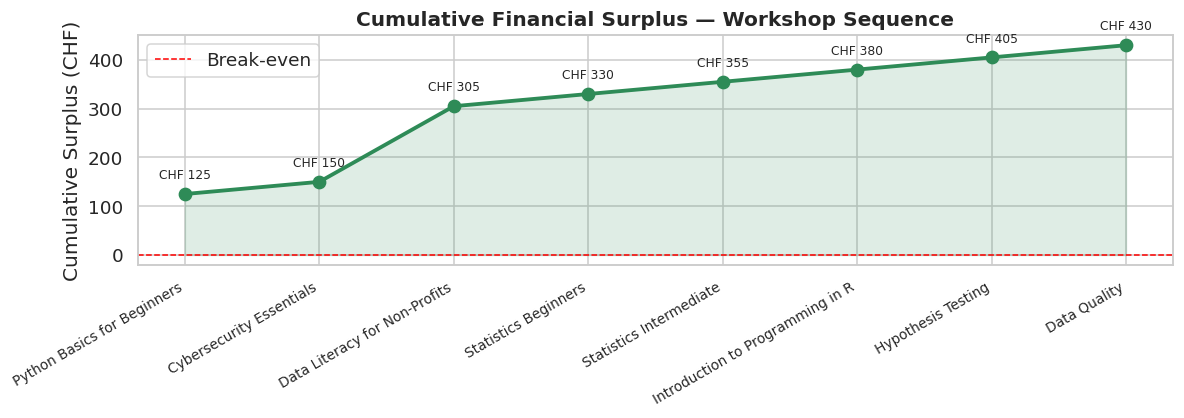


Total programme surplus (all workshops): CHF 430.00
The programme is above break-even after every single workshop.


In [5]:
# ─── Cell 5 · Cumulative surplus over time (waterfall view) ───────────────────
# A cumulative surplus chart shows whether the programme is building financial
# reserves — a critical indicator of long-term sustainability.
ws_sorted = ws.sort_values("date").reset_index(drop=True)
ws_sorted["cumulative_surplus"] = ws_sorted["surplus_chf"].cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ws_sorted["name"], ws_sorted["cumulative_surplus"],
        marker="o", linewidth=2.5, markersize=8, color="seagreen")
ax.fill_between(range(len(ws_sorted)), ws_sorted["cumulative_surplus"], alpha=0.15, color="seagreen")
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="Break-even")

for i, row in ws_sorted.iterrows():
    ax.annotate(f"CHF {row['cumulative_surplus']:.0f}",
                (i, row["cumulative_surplus"]), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8)

ax.set_xticklabels(ws_sorted["name"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Cumulative Surplus (CHF)")
ax.set_title("Cumulative Financial Surplus — Workshop Sequence", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

total_surplus = ws_sorted["surplus_chf"].sum()
print(f"\nTotal programme surplus (all workshops): CHF {total_surplus:.2f}")
print("The programme is above break-even after every single workshop.")

Revenue / Cost / Surplus by format:
        revenue_chf  total_cost_chf  surplus_chf
format                                          
Online        750.0           600.0        150.0
Onsite        750.0           470.0        280.0


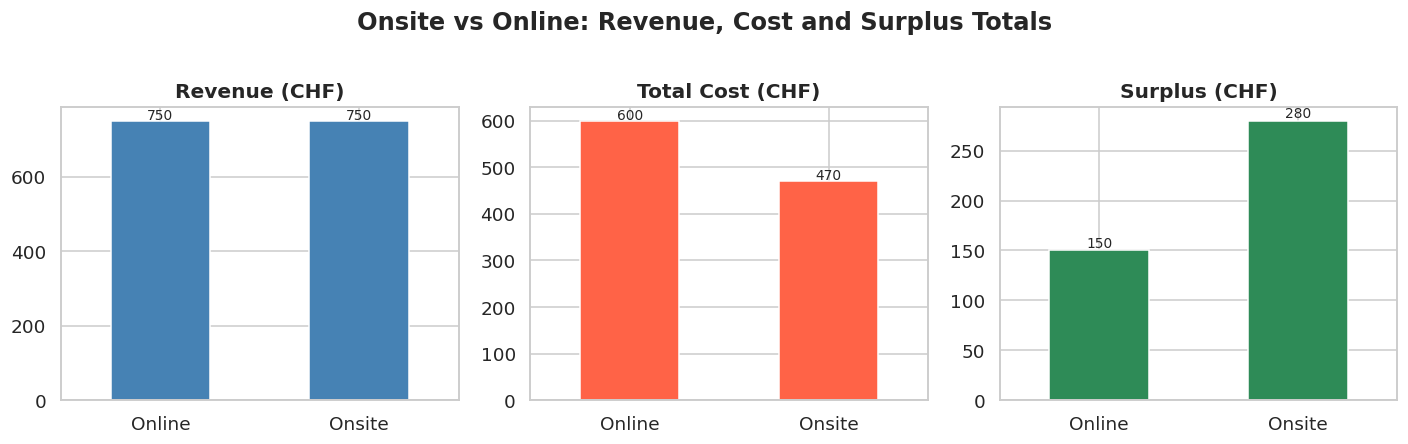


Average net margin % by format:
format
Online    20.0
Onsite    37.3
Name: margin_pct, dtype: float64


In [6]:
# ─── Cell 6 · Revenue structure: onsite vs online ─────────────────────────────
# Onsite workshops (CHF 15/seat) and online workshops (CHF 5/seat) have very
# different unit economics. Understanding the mix matters for planning.
rev_by_format = ws.groupby(ws["workshop_id"].str.contains("001|003").map({True: "Onsite", False: "Online"}))[
    ["revenue_chf", "total_cost_chf", "surplus_chf"]
].sum().rename_axis("Format")

# Cleaner approach using a derived column
ws["format"] = ws["n_paid_onsite"].apply(lambda x: "Onsite" if x > 0 else "Online")
rev_by_format = ws.groupby("format")[["revenue_chf", "total_cost_chf", "surplus_chf"]].sum()
print("Revenue / Cost / Surplus by format:")
print(rev_by_format)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ["revenue_chf", "total_cost_chf", "surplus_chf"]
titles  = ["Revenue (CHF)", "Total Cost (CHF)", "Surplus (CHF)"]
colors  = ["steelblue", "tomato", "seagreen"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    rev_by_format[metric].plot(kind="bar", ax=ax, color=color, width=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f"{bar.get_height():.0f}", ha="center", fontsize=9)

plt.suptitle("Onsite vs Online: Revenue, Cost and Surplus Totals", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Insight: although onsite brings more revenue per workshop, online has lower costs
# and together they both contribute positively to the surplus.
ws_format_margin = ws.groupby("format")["margin_pct"].mean().round(1)
print("\nAverage net margin % by format:")
print(ws_format_margin)

---
## Section 3 — Q5: How much money is available for the next iteration?

**Why this matters**  
The surplus generated in the current period is the *investment budget* for the next one.  
Knowing the exact figure lets the team plan whether to add workshops, upgrade tools, or increase the free-seat quota without external funding.

**Note on Q1 2026 scope:**  
Workshops 1–3 (January–March 2026) fall strictly in Q1.  
Workshops 4–8 extend into Q2/Q3 2026 in the synthetic data.  
We therefore show both the strict Q1 figure and the full programme figure.

In [7]:
# ─── Cell 7 · Q1 2026 surplus calculation ─────────────────────────────────────
ws_q1 = ws[ws["quarter"] == "2026Q1"].copy()
ws_full = ws.copy()

q1_revenue  = ws_q1["revenue_chf"].sum()
q1_cost     = ws_q1["total_cost_chf"].sum()
q1_surplus  = ws_q1["surplus_chf"].sum()

full_revenue = ws_full["revenue_chf"].sum()
full_cost    = ws_full["total_cost_chf"].sum()
full_surplus = ws_full["surplus_chf"].sum()

print("=" * 52)
print(f"  Q1 2026 only ({len(ws_q1)} workshops):")
print(f"    Revenue :  CHF {q1_revenue:>8.2f}")
print(f"    Cost    :  CHF {q1_cost:>8.2f}")
print(f"    SURPLUS :  CHF {q1_surplus:>8.2f}")
print("=" * 52)
print(f"  Full programme ({len(ws_full)} workshops):")
print(f"    Revenue :  CHF {full_revenue:>8.2f}")
print(f"    Cost    :  CHF {full_cost:>8.2f}")
print(f"    SURPLUS :  CHF {full_surplus:>8.2f}")
print("=" * 52)
print(f"\n→ CHF {q1_surplus:.2f} is available from Q1 2026 for immediate reinvestment.")
print(f"→ CHF {full_surplus:.2f} is the total programme surplus to date.")

  Q1 2026 only (3 workshops):
    Revenue :  CHF   875.00
    Cost    :  CHF   570.00
    SURPLUS :  CHF   305.00
  Full programme (8 workshops):
    Revenue :  CHF  1500.00
    Cost    :  CHF  1070.00
    SURPLUS :  CHF   430.00

→ CHF 305.00 is available from Q1 2026 for immediate reinvestment.
→ CHF 430.00 is the total programme surplus to date.


In [8]:
# ─── Cell 8 · Future revenue forecast (upcoming workshops) ────────────────────
# We load the planned upcoming workshops and simulate expected revenue/cost/surplus
# assuming the same participant structure (25 paid online + 5 free).
upcoming = pd.read_csv(DATA_DIR / "upcoming_workshops.csv")
print("Upcoming workshops:")
print(upcoming)

ONLINE_PRICE   = 5.0    # CHF per paid online seat
PAID_SEATS     = 25     # paid participants per workshop
FREE_SEATS     = 5      # free participants per workshop
INSTRUCTOR_CHF = 100.0  # fixed instructor cost
VENUE_CHF_ONLINE = 0.0  # no venue for online

upcoming["expected_revenue_chf"] = PAID_SEATS * ONLINE_PRICE
upcoming["expected_cost_chf"]    = INSTRUCTOR_CHF + VENUE_CHF_ONLINE
upcoming["expected_surplus_chf"] = upcoming["expected_revenue_chf"] - upcoming["expected_cost_chf"]

total_future_surplus = upcoming["expected_surplus_chf"].sum()
print(f"\nExpected surplus from {len(upcoming)} upcoming online workshops: CHF {total_future_surplus:.2f}")
print(f"Combined with Q1 surplus: CHF {q1_surplus + total_future_surplus:.2f} available for reinvestment")

print("\n" + upcoming[["name", "modality", "date", "expected_revenue_chf",
                        "expected_cost_chf", "expected_surplus_chf"]].to_string(index=False))

Upcoming workshops:
   sequence                              name modality        date
0         1              Statistics Beginners   online  2026-07-05
1         2           Statistics Intermediate   online  2026-07-19
2         3  Introduction to Programming in R   online  2026-08-03
3         4                Hypothesis Testing   online  2026-08-17
4         5                      Data Quality   online  2026-08-31

Expected surplus from 5 upcoming online workshops: CHF 125.00
Combined with Q1 surplus: CHF 430.00 available for reinvestment

                            name modality       date  expected_revenue_chf  expected_cost_chf  expected_surplus_chf
            Statistics Beginners   online 2026-07-05                 125.0              100.0                  25.0
         Statistics Intermediate   online 2026-07-19                 125.0              100.0                  25.0
Introduction to Programming in R   online 2026-08-03                 125.0              100.0         

---
## Section 4 — Q6: How much can we increase the free-seat percentage while staying sustainable?

**Why this matters**  
The free-seat policy is the programme's core equity mechanism: it ensures that people who cannot afford even CHF 5–15 still have access to digital education.  
The question is: *how far can we stretch this commitment before the programme loses money?*

**Method**  
We model the **break-even free-seat percentage** for each format (onsite/online):  
- Total seats = paid + free = constant (30)  
- Revenue = paid_seats × price = (30 − free_seats) × price  
- Break-even condition: Revenue ≥ Cost  
- Break-even free seats = 30 − ⌈ Cost / price ⌉

In [9]:
# ─── Cell 9 · Break-even free-seat analysis ───────────────────────────────────
import math

TOTAL_SEATS   = 30
ONSITE_PRICE  = 15.0
ONLINE_PRICE  = 5.0
COST_ONSITE   = 250.0   # venue 150 + instructor 100 (worst-case venue)
COST_ONLINE   = 100.0   # instructor only

# Break-even free seats = total_seats - ceil(cost / price)
breakeven_free_onsite  = TOTAL_SEATS - math.ceil(COST_ONSITE / ONSITE_PRICE)
breakeven_free_online  = TOTAL_SEATS - math.ceil(COST_ONLINE / ONLINE_PRICE)

breakeven_pct_onsite = breakeven_free_onsite / TOTAL_SEATS * 100
breakeven_pct_online = breakeven_free_online / TOTAL_SEATS * 100

current_pct = ws["free_seat_pct"].mean()

print(f"Current free-seat rate (programme average): {current_pct:.1f}%")
print()
print(f"ONSITE workshops (price CHF {ONSITE_PRICE}, max cost CHF {COST_ONSITE}):")
print(f"  Break-even free seats: {breakeven_free_onsite} of {TOTAL_SEATS} = {breakeven_pct_onsite:.1f}%")
print(f"  Current free seats   : 5 of 30 = 16.7% → headroom: +{breakeven_pct_onsite - 16.7:.1f} pp")
print()
print(f"ONLINE workshops (price CHF {ONLINE_PRICE}, cost CHF {COST_ONLINE}):")
print(f"  Break-even free seats: {breakeven_free_online} of {TOTAL_SEATS} = {breakeven_pct_online:.1f}%")
print(f"  Current free seats   : 5 of 30 = 16.7% → headroom: +{breakeven_pct_online - 16.7:.1f} pp")

Current free-seat rate (programme average): 16.7%

ONSITE workshops (price CHF 15.0, max cost CHF 250.0):
  Break-even free seats: 13 of 30 = 43.3%
  Current free seats   : 5 of 30 = 16.7% → headroom: +26.6 pp

ONLINE workshops (price CHF 5.0, cost CHF 100.0):
  Break-even free seats: 10 of 30 = 33.3%
  Current free seats   : 5 of 30 = 16.7% → headroom: +16.6 pp


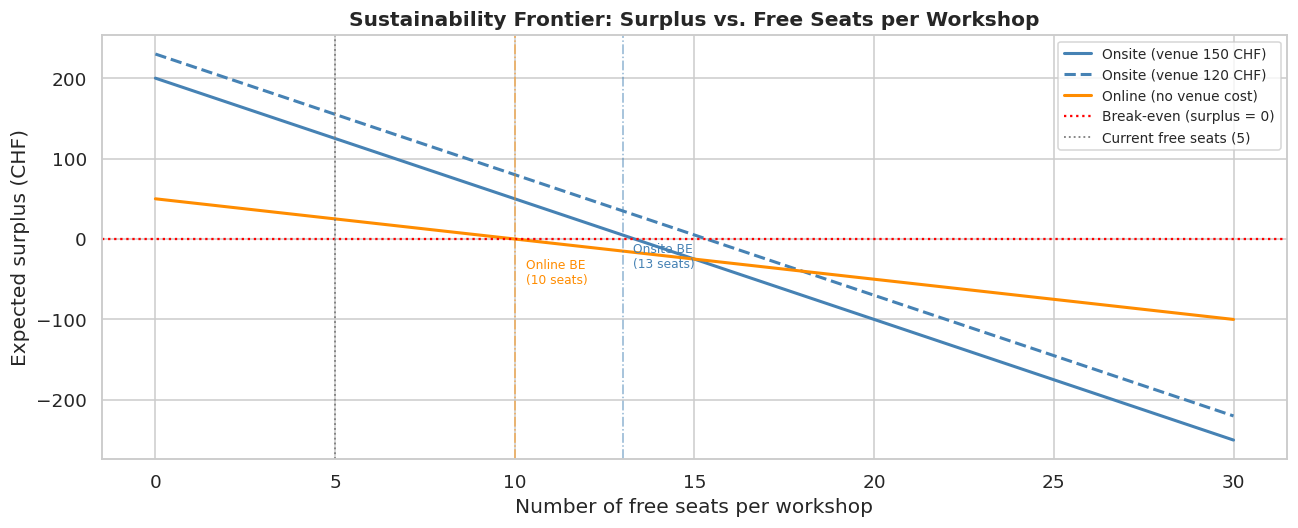

Reading the chart:
  Onsite workshops can support up to 13 free seats (43%) before losing money.
  Online workshops can support up to 10 free seats (33%) before losing money.
  Current policy: 5 free seats = 16.7% — well inside the sustainable zone for both formats.


In [10]:
# ─── Cell 10 · Sensitivity curve: surplus vs free-seat percentage ──────────────
# This chart shows the full sustainability frontier for each format:
# the x-axis is the number of free seats; y-axis is the expected surplus.
# The red dotted line marks break-even (surplus = 0).

free_seats_range = np.arange(0, 31)

surplus_onsite_max = (TOTAL_SEATS - free_seats_range) * ONSITE_PRICE - COST_ONSITE
surplus_online     = (TOTAL_SEATS - free_seats_range) * ONLINE_PRICE - COST_ONLINE

# Best-case onsite (venue cost 120 CHF instead of 150 CHF)
COST_ONSITE_LOW = 220.0
surplus_onsite_low = (TOTAL_SEATS - free_seats_range) * ONSITE_PRICE - COST_ONSITE_LOW

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(free_seats_range, surplus_onsite_max, label="Onsite (venue 150 CHF)",  color="steelblue", linewidth=2)
ax.plot(free_seats_range, surplus_onsite_low, label="Onsite (venue 120 CHF)",  color="steelblue", linewidth=2, linestyle="--")
ax.plot(free_seats_range, surplus_online,     label="Online (no venue cost)",  color="darkorange", linewidth=2)

ax.axhline(0, color="red", linestyle=":", linewidth=1.5, label="Break-even (surplus = 0)")
ax.axvline(5, color="gray", linestyle=":", linewidth=1.2, label="Current free seats (5)")

# Mark break-even points
ax.axvline(breakeven_free_onsite, color="steelblue", linestyle="-.", linewidth=1, alpha=0.6)
ax.axvline(breakeven_free_online, color="darkorange", linestyle="-.", linewidth=1, alpha=0.6)

ax.text(breakeven_free_onsite + 0.3, -35, f"Onsite BE\n({breakeven_free_onsite} seats)",
        color="steelblue", fontsize=8)
ax.text(breakeven_free_online + 0.3, -55, f"Online BE\n({breakeven_free_online} seats)",
        color="darkorange", fontsize=8)

ax.set_xlabel("Number of free seats per workshop")
ax.set_ylabel("Expected surplus (CHF)")
ax.set_title("Sustainability Frontier: Surplus vs. Free Seats per Workshop", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Reading the chart:")
print(f"  Onsite workshops can support up to {breakeven_free_onsite} free seats ({breakeven_pct_onsite:.0f}%) before losing money.")
print(f"  Online workshops can support up to {breakeven_free_online} free seats ({breakeven_pct_online:.0f}%) before losing money.")
print(f"  Current policy: 5 free seats = 16.7% — well inside the sustainable zone for both formats.")

---
## Section 5 — Q7: How many extra free seats can we offer with the Q1 2026 surplus?

**Why this matters**  
The surplus already generated is *real money* the organisation has.  
Instead of leaving it as a cash reserve, the team can choose to convert it into **additional free seats** in future workshops.  
This bridges financial analysis directly to the social mission: every CHF of surplus that comes from online workshops costs CHF 5 per extra free-seat-edition, and from onsite workshops costs CHF 15 per extra free-seat-edition.

**Approach**  
We ask: *if the Q1 surplus were entirely used to subsidise extra free seats in the next batch of workshops, how many more participants could we serve for free?*

In [11]:
# ─── Cell 11 · Extra free seats from Q1 2026 surplus ──────────────────────────
# The opportunity cost of a free seat equals the price the participant would have paid.
# For online workshops (the majority of upcoming): CHF 5 per extra free seat.
# For onsite workshops: CHF 15 per extra free seat.

print(f"Q1 2026 surplus available: CHF {q1_surplus:.2f}")
print(f"Full programme surplus available: CHF {full_surplus:.2f}")
print()

for surplus_label, surplus_val in [("Q1 only", q1_surplus), ("Full programme", full_surplus)]:
    extra_online = int(surplus_val // ONLINE_PRICE)
    extra_onsite = int(surplus_val // ONSITE_PRICE)
    sessions_online = extra_online // TOTAL_SEATS  # how many full workshops that covers
    print(f"  [{surplus_label} — CHF {surplus_val:.0f}]")
    print(f"    → Extra free seats if all online (CHF 5/seat): {extra_online} seats"
          f"  ≈ {extra_online/TOTAL_SEATS:.1f} full workshops")
    print(f"    → Extra free seats if all onsite (CHF 15/seat): {extra_onsite} seats"
          f"  ≈ {extra_onsite/TOTAL_SEATS:.1f} full workshops")
    print()

Q1 2026 surplus available: CHF 305.00
Full programme surplus available: CHF 430.00

  [Q1 only — CHF 305]
    → Extra free seats if all online (CHF 5/seat): 61 seats  ≈ 2.0 full workshops
    → Extra free seats if all onsite (CHF 15/seat): 20 seats  ≈ 0.7 full workshops

  [Full programme — CHF 430]
    → Extra free seats if all online (CHF 5/seat): 86 seats  ≈ 2.9 full workshops
    → Extra free seats if all onsite (CHF 15/seat): 28 seats  ≈ 0.9 full workshops



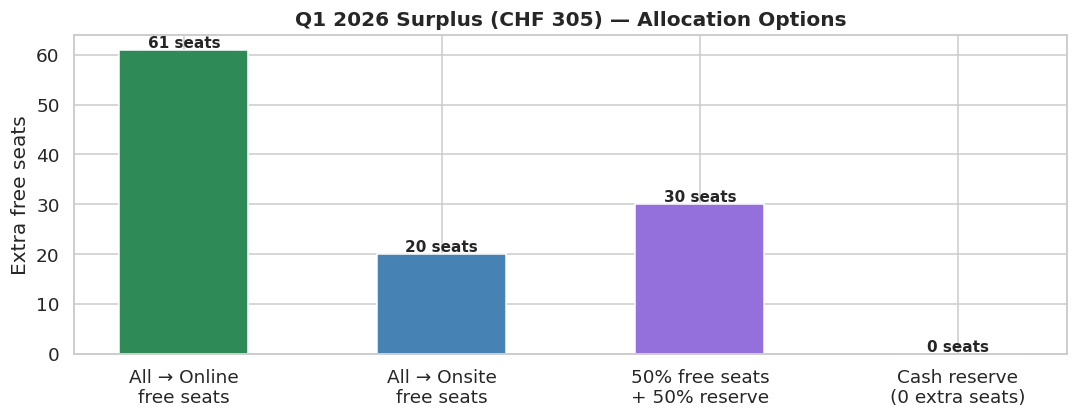


Recommendation: allocating the Q1 surplus to online workshops would fund
61 extra free seats — enough for 12 more free participants per future workshop (adding 12 to each upcoming session).


In [12]:
# ─── Cell 12 · Visual: surplus allocation options ──────────────────────────────
# This chart shows different ways the Q1 surplus could be allocated:
# option A — extra free seats in online workshops
# option B — extra free seats in onsite workshops
# option C — reserve all as a financial buffer
# option D — split 50/50 free seats + buffer

fig, ax = plt.subplots(figsize=(10, 4))

options = {
    "All → Online\nfree seats": int(q1_surplus // ONLINE_PRICE),
    "All → Onsite\nfree seats": int(q1_surplus // ONSITE_PRICE),
    "50% free seats\n+ 50% reserve": int((q1_surplus * 0.5) // ONLINE_PRICE),
    "Cash reserve\n(0 extra seats)": 0,
}

colors_opt = ["seagreen", "steelblue", "mediumpurple", "gray"]
bars = ax.bar(options.keys(), options.values(), color=colors_opt, width=0.5)
for bar, val in zip(bars, options.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val} seats", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Extra free seats")
ax.set_title(f"Q1 2026 Surplus (CHF {q1_surplus:.0f}) — Allocation Options", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nRecommendation: allocating the Q1 surplus to online workshops would fund")
print(f"{int(q1_surplus // ONLINE_PRICE)} extra free seats — enough for {int(q1_surplus // ONLINE_PRICE / 5):.0f}"
      f" more free participants per future workshop (adding {int(q1_surplus // ONLINE_PRICE / 5):.0f} to each upcoming session).")

---
## Section 6 — Growth-adjusted sustainability: can we grow AND stay in the green?

**Why this matters**  
Sustainability is not just about the current period — it is about whether the programme can grow *without* requiring external grants.  
We model what happens to the annual surplus under three growth scenarios:  
- **Baseline**: same format mix (3 onsite + 5 online per cycle)  
- **Growth A**: add 2 more online workshops per cycle  
- **Growth B**: add 1 more onsite + 1 more online per cycle  

Average surplus per onsite workshop: CHF 140.00
Average surplus per online workshop: CHF 25.00

                                 Workshops  Total participants  Free seats  Annual surplus (CHF)
Scenario                                                                                        
Baseline\n(3 onsite + 5 online)          8                 240          40                 545.0
Growth A\n(3 onsite + 7 online)         10                 300          50                 595.0
Growth B\n(4 onsite + 6 online)         10                 300          50                 710.0
Growth C\n(2 onsite + 8 online)         10                 300          50                 480.0


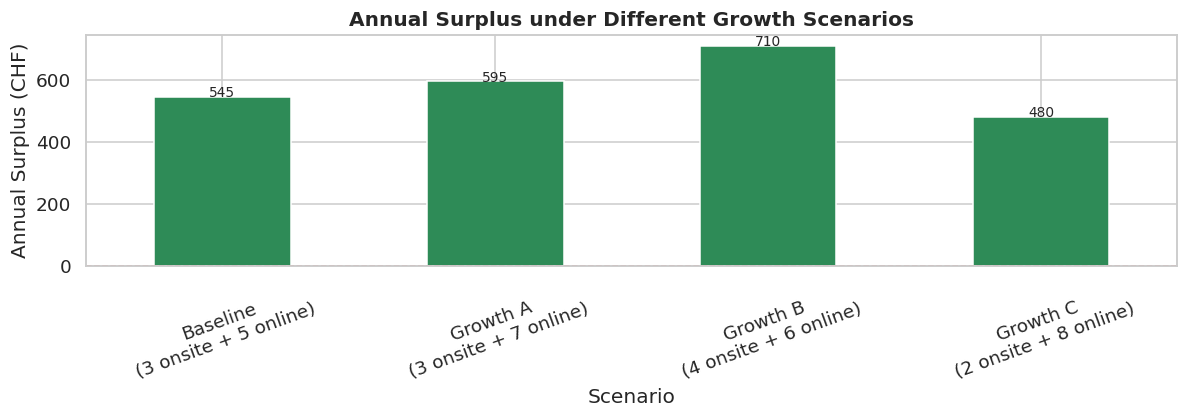


All growth scenarios produce a positive surplus.
The programme can grow without requiring external grants.


In [13]:
# ─── Cell 13 · Scenario analysis: annual surplus under growth scenarios ─────────
scenarios = {
    "Baseline\n(3 onsite + 5 online)": {"onsite": 3, "online": 5},
    "Growth A\n(3 onsite + 7 online)": {"onsite": 3, "online": 7},
    "Growth B\n(4 onsite + 6 online)": {"onsite": 4, "online": 6},
    "Growth C\n(2 onsite + 8 online)": {"onsite": 2, "online": 8},
}

# Per-workshop surplus: onsite uses average observed surplus; online uses observed average
avg_surplus_onsite = ws[ws["format"] == "Onsite"]["surplus_chf"].mean()
avg_surplus_online = ws[ws["format"] == "Online"]["surplus_chf"].mean()

print(f"Average surplus per onsite workshop: CHF {avg_surplus_onsite:.2f}")
print(f"Average surplus per online workshop: CHF {avg_surplus_online:.2f}")
print()

results = []
for label, cfg in scenarios.items():
    total_s = cfg["onsite"] * avg_surplus_onsite + cfg["online"] * avg_surplus_online
    total_participants = (cfg["onsite"] + cfg["online"]) * TOTAL_SEATS
    total_free         = (cfg["onsite"] + cfg["online"]) * FREE_SEATS
    results.append({"Scenario": label, "Workshops": cfg["onsite"]+cfg["online"],
                    "Total participants": total_participants,
                    "Free seats": total_free,
                    "Annual surplus (CHF)": round(total_s, 2)})

results_df = pd.DataFrame(results).set_index("Scenario")
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
results_df["Annual surplus (CHF)"].plot(kind="bar", ax=ax, color="seagreen", width=0.5)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_ylabel("Annual Surplus (CHF)")
ax.set_title("Annual Surplus under Different Growth Scenarios", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nAll growth scenarios produce a positive surplus.")
print("The programme can grow without requiring external grants.")

---
## Section 7 — Summary and conclusions

The cells below consolidate the key financial findings into a single printed summary table.

In [14]:
# ─── Cell 14 · Financial KPI dashboard ────────────────────────────────────────
kpis = {
    "Total workshops run": len(ws),
    "Total participants served": ws["participants_total"].sum(),
    "Total free seats": ws["n_free"].sum(),
    "Free seat rate (%)": f"{ws['free_seat_pct'].mean():.1f}%",
    "Total revenue (CHF)": f"{ws['revenue_chf'].sum():.2f}",
    "Total cost (CHF)": f"{ws['total_cost_chf'].sum():.2f}",
    "Total surplus (CHF)": f"{ws['surplus_chf'].sum():.2f}",
    "Q1 2026 surplus (CHF)": f"{q1_surplus:.2f}",
    "All workshops profitable": str((ws['surplus_chf'] > 0).all()),
    "Max free seats (onsite, break-even)": f"{breakeven_free_onsite} ({breakeven_pct_onsite:.0f}%)",
    "Max free seats (online, break-even)": f"{breakeven_free_online} ({breakeven_pct_online:.0f}%)",
    "Extra free seats from Q1 surplus (online)": int(q1_surplus // ONLINE_PRICE),
    "Extra free seats from Q1 surplus (onsite)": int(q1_surplus // ONSITE_PRICE),
}

print("\n" + "═" * 60)
print("   FINANCIAL SUSTAINABILITY KPI DASHBOARD — Q1/Q2 2026")
print("═" * 60)
for k, v in kpis.items():
    print(f"  {k:<45} {v}")
print("═" * 60)
print("\nConclusion: The digital skills programme is financially")
print("sustainable. Every workshop produced a surplus.")
print("The current free-seat policy (16.7%) leaves significant")
print("headroom before break-even — the organisation can increase")
print("free access without endangering its finances.")


════════════════════════════════════════════════════════════
   FINANCIAL SUSTAINABILITY KPI DASHBOARD — Q1/Q2 2026
════════════════════════════════════════════════════════════
  Total workshops run                           8
  Total participants served                     240
  Total free seats                              40
  Free seat rate (%)                            16.7%
  Total revenue (CHF)                           1500.00
  Total cost (CHF)                              1070.00
  Total surplus (CHF)                           430.00
  Q1 2026 surplus (CHF)                         305.00
  All workshops profitable                      True
  Max free seats (onsite, break-even)           13 (43%)
  Max free seats (online, break-even)           10 (33%)
  Extra free seats from Q1 surplus (online)     61
  Extra free seats from Q1 surplus (onsite)     20
════════════════════════════════════════════════════════════

Conclusion: The digital skills programme is financially
sustai